In [652]:
import os
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pickle
from plotly import express as px


In [653]:
# Thiết lập chung
ds_path = 'datasets/titanic/'
train_path = os.path.join(ds_path, 'train.csv')
test_path = os.path.join(ds_path, 'test.csv')

In [654]:
# Giải nén tập dữ liệu
with zipfile.ZipFile('datasets/titanic.zip', 'r') as f:
	f.extractall(ds_path)

In [655]:
# Nạp dữ liệu
train_ds = pd.read_csv(train_path, delimiter=',')
test_ds = pd.read_csv(test_path, delimiter=',')
train_ds.sample(50)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
809,810,1,1,"Chambers, Mrs. Norman Campbell (Bertha Griggs)",female,33.00,1,0,113806,53.1000,E8,S
49,50,0,3,"Arnold-Franchi, Mrs. Josef (Josefine Franchi)",female,18.00,1,0,349237,17.8000,NaN,S
589,590,0,3,"Murdlin, Mr. Joseph",male,NaN,0,0,A./5. 3235,8.0500,NaN,S
312,313,0,2,"Lahtinen, Mrs. William (Anna Sylfven)",female,26.00,1,1,250651,26.0000,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.5500,NaN,S
254,255,0,3,"Rosblom, Mrs. Viktor (Helena Wilhelmina)",female,41.00,0,2,370129,20.2125,NaN,S
417,418,1,2,"Silven, Miss. Lyyli Karoliina",female,18.00,0,2,250652,13.0000,NaN,S
300,301,1,3,"Kelly, Miss. Anna Katherine ""Annie Kate""",female,NaN,0,0,9234,7.7500,NaN,Q
64,65,0,1,"Stewart, Mr. Albert A",male,NaN,0,0,PC 17605,27.7208,NaN,C
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.00,3,2,19950,263.0000,C23 C25 C27,S


In [656]:
train_ds.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [657]:
# Loại bỏ thuộc tính dư thừa
train_ds.drop(columns=['Name', 'PassengerId', 'Ticket'], inplace=True)
train_ds.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin',
       'Embarked'],
      dtype='object')

In [658]:

# Xử lý cột Cabin
train_ds['HasCabin'] = np.where(train_ds['Cabin'].isna(), 0, 1)  # Nếu Cabin != N/A thì hascabin = 0 else 1
train_ds.drop(columns=['Cabin'], inplace=True)  # Loại bỏ cột Cabin


In [659]:
# Kiểm tra giá trị N/A (Train)
train_ds = train_ds.bfill().ffill()
train_ds.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
HasCabin    0
dtype: int64

In [660]:
## Xử lý cột Sex
sex = sorted(train_ds['Sex'].unique())
print('Sex label:', sex)
train_ds['Sex'].replace(sex, range(len(sex)), inplace=True)
train_ds['Sex'].sample(10)

Sex label: ['female', 'male']


699    1
394    0
651    0
37     1
714    1
177    0
760    1
747    0
236    1
533    0
Name: Sex, dtype: int64

In [661]:
## Xử lý cột Embarked
embarked = sorted(train_ds['Embarked'].unique())
print('Embarked label:', embarked)
train_ds['Embarked'].replace(embarked, range(len(embarked)), inplace=True)
train_ds['Embarked'].sample(10)

Embarked label: ['C', 'Q', 'S']


647    0
472    2
757    2
119    2
797    2
80     2
439    2
614    2
137    2
350    2
Name: Embarked, dtype: int64

In [662]:
## Kiểm tra kiểu dữ liệu
train_ds.dtypes

Survived      int64
Pclass        int64
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked      int64
HasCabin      int32
dtype: object

Survived    0.478523
Pclass     -0.630548
Sex        -0.618921
Age         0.342346
SibSp       3.695352
Parch       2.749117
Fare        4.787317
Embarked   -1.257476
HasCabin    1.292367
dtype: float64


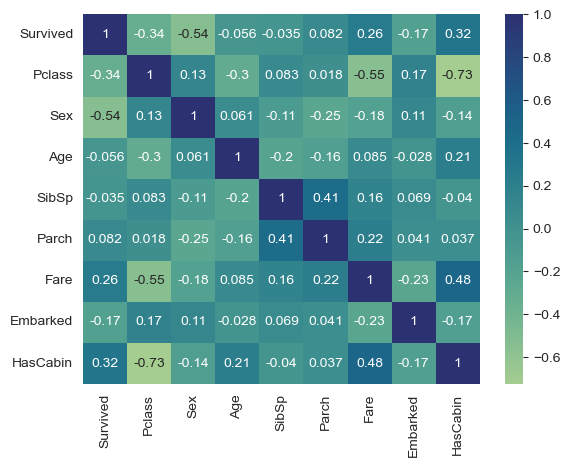

In [663]:
print(train_ds.skew())

sns.heatmap(train_ds.corr(), cmap='crest', annot=True)
plt.show()

In [664]:
# Chuyển kiểu dữ liệu
train_ds['Age'] = train_ds['Age'].astype(int)  # Age -> Int
train_ds['Fare'] = train_ds['Fare'].astype(float)  # Fare -> Float

train_ds.dtypes

Survived      int64
Pclass        int64
Sex           int64
Age           int32
SibSp         int64
Parch         int64
Fare        float64
Embarked      int64
HasCabin      int32
dtype: object

In [665]:
# Chuẩn hóa giá trị
StandardScaler().fit_transform(train_ds)
train_ds.describe()

C:\Users\Bao\anaconda3\Lib\site-packages\sklearn\utils\validation.py:767: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

C:\Users\Bao\anaconda3\Lib\site-packages\sklearn\utils\validation.py:605: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

C:\Users\Bao\anaconda3\Lib\site-packages\sklearn\utils\validation.py:614: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

C:\Users\Bao\anaconda3\Lib\site-packages\sklearn\utils\validation.py:767: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

C:\Users\Bao\anaconda3\Lib\site-packages\sklearn\utils\validation.py:605: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,HasCabin
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.647587,29.846240,0.523008,0.381594,32.204208,1.534231,0.228956
std,0.486592,0.836071,0.477990,14.616288,1.102743,0.806057,49.693429,0.793021,0.420397
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,21.000000,0.000000,0.000000,7.910400,1.000000,0.000000
50%,0.000000,3.000000,1.000000,29.000000,0.000000,0.000000,14.454200,2.000000,0.000000
75%,1.000000,3.000000,1.000000,39.000000,1.000000,0.000000,31.000000,2.000000,0.000000
max,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200,2.000000,1.000000


In [666]:
# Trực quan hóa dữ liệu
px.bar(
	train_ds,
	x='Pclass',
	y='Survived',
	color='Pclass',
	title='Tỉ lệ sống sót dựa trên hạng vé Pclass'
).show()

In [667]:
px.pie(
	train_ds,
	names='Survived',
	values='Sex',
	color='Sex',
	title='Tỉ lệ sống sót dựa trên giới tính Sex',
).show()

In [668]:
px.pie(
	train_ds,
	names='Survived',
	values='HasCabin',
	color='HasCabin',
	title='Tỉ lệ sống sót dựa trên HasCabin',
).show()

In [669]:
px.bar(
	train_ds,
	x='Age',
	y='Survived',
	color='Age',
	title='Tỉ lệ sống sót theo độ tuổi'
).show()

In [670]:
# Nạp dữ liệu cho mảng để Train
x = train_ds.drop(columns=['Survived'])
y = train_ds['Survived']

C:\Users\Bao\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

C:\Users\Bao\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

C:\Users\Bao\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead



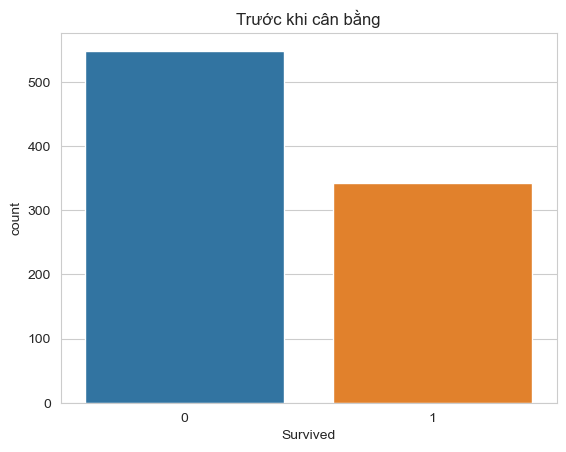

In [671]:
# Kiểm tra & tái cân bằng nhãn (nếu có)
plt.title('Trước khi cân bằng')
sns.countplot(train_ds, x='Survived')
plt.show()
# => Nhãn chưa cân bằng

In [672]:
# Tái cân bằng nhãn
a = RandomOverSampler(random_state=50)  # Tỉ lệ ngẫu nhiên là 50% (Set cố định để khi Train chọn thuạt toán tốt nhất)
x, y = a.fit_resample(x, y)

C:\Users\Bao\anaconda3\Lib\site-packages\sklearn\utils\validation.py:605: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

C:\Users\Bao\anaconda3\Lib\site-packages\sklearn\utils\validation.py:614: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

C:\Users\Bao\anaconda3\Lib\site-packages\sklearn\utils\validation.py:767: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

C:\Users\Bao\anaconda3\Lib\site-packages\sklearn\utils\validation.py:605: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

C:\Users\Bao\anaconda3\Lib\site-packages\sklearn\utils\validation.py:614: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance

C:\Users\Bao\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

C:\Users\Bao\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

C:\Users\Bao\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead



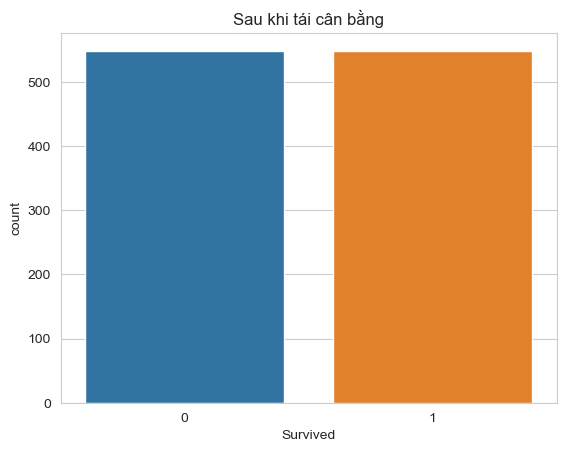

In [673]:
plt.title('Sau khi tái cân bằng')
sns.countplot(x=y)
plt.show()

In [674]:
# Tách tập dữ liệu
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.2, stratify=y, random_state=50)

C:\Users\Bao\anaconda3\Lib\site-packages\sklearn\utils\validation.py:605: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

C:\Users\Bao\anaconda3\Lib\site-packages\sklearn\utils\validation.py:614: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.



In [675]:
model = RandomForestClassifier()
model.fit(x_train, y_train)

# Lưu mô hình
with open('titatic_model.pkl', 'wb') as f:
	pickle.dump(model, f)

C:\Users\Bao\anaconda3\Lib\site-packages\sklearn\utils\validation.py:767: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

C:\Users\Bao\anaconda3\Lib\site-packages\sklearn\utils\validation.py:605: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

C:\Users\Bao\anaconda3\Lib\site-packages\sklearn\utils\validation.py:614: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

C:\Users\Bao\anaconda3\Lib\site-packages\sklearn\utils\validation.py:605: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

C:\Users\Bao\anaconda3\Lib\site-packages\sklearn\utils\validation.py:614: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance

== TRAIN ==
Score: 0.9886104783599089
MSE: 0.011389521640091117
R2_Score: 0.9544419134396356
== TEST ==
Score: 0.9886104783599089
MSE: 0.11818181818181818
R2_Score: 0.5272727272727273


C:\Users\Bao\anaconda3\Lib\site-packages\sklearn\utils\validation.py:767: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

C:\Users\Bao\anaconda3\Lib\site-packages\sklearn\utils\validation.py:605: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

C:\Users\Bao\anaconda3\Lib\site-packages\sklearn\utils\validation.py:614: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

C:\Users\Bao\anaconda3\Lib\site-packages\sklearn\utils\validation.py:605: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

C:\Users\Bao\anaconda3\Lib\site-packages\sklearn\utils\validation.py:614: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance

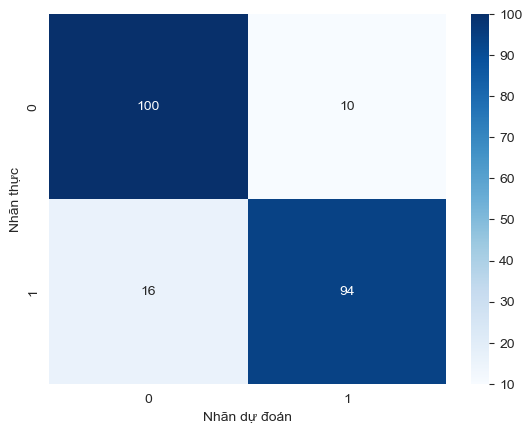

In [676]:
# Đánh giá mô hình
print('== TRAIN ==')
print('Score:', model.score(x_train, y_train))

# Tỉ lệ lỗi của mô hình
y_pred = model.predict(x_train)
mse = mean_squared_error(y_train, y_pred)
print('MSE:', mse)
r2 = r2_score(y_train, y_pred)
print('R2_Score:', r2)

print('== TEST ==')
print('Score:', model.score(x_train, y_train))
# Tỉ lệ lỗi của mô hình
y_pred = model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
print('MSE:', mse)
r2 = r2_score(y_test, y_pred)
print('R2_Score:', r2)

y_pred = model.predict(x_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
plt.xlabel('Nhãn dự đoán')
plt.ylabel('Nhãn thực')
plt.show()

In [677]:
class_names = ['No Survived', 'Survived']
print(train_ds.columns)

def model_pred(data):
	data = np.reshape(data, (1, 8))
	print('=> Kết quả:', class_names[model.predict(data)[0]])

pred = [1, 0, 22, 0, 1, 14.5, 0]
pred_2 = [2, 1, 63, 1, 0, 26, 2]
pred_3 = [1, 0, 45, 1, 0, 52.5542, 2]
pred_4 = [1, 0, 23, 1, 0, 82.2667, 2, 1]

# model_pred(pred)
# model_pred(pred_2)
# model_pred(pred_3)
model_pred(pred_4)


Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'HasCabin'],
      dtype='object')
=> Kết quả: Survived


C:\Users\Bao\anaconda3\Lib\site-packages\sklearn\base.py:420: UserWarning:

X does not have valid feature names, but RandomForestClassifier was fitted with feature names

